# 1. Environment Setup

## 1.1 Install libraries

In [1]:
import sys
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'pyarrow': 'pyarrow',
    'pillow': 'pillow',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn', 
    'nltk': 'nltk',
}


print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 

Installation complete. 



## 1.2 Import Libraries

In [2]:
# GPU Detection, Package Installation, and Library Verification
import os
import warnings
import logging
from dotenv import load_dotenv

import re
import html
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load environment variables from .env file
load_dotenv()

# Download required NLTK data (if not already downloaded)
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


import torch
import time
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

from transformers import (
    DistilBertTokenizer,
    DistilBertModel
)

import torchvision
import transformers

from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import lime
import lime.lime_text
import lime.lime_tabular
import cv2
from scipy.special import softmax


from transformers.utils import logging as hf_logging

# Disable Hugging Face symlink warning
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
if os.getenv("HUGGING_FACE_TOKEN"):
    os.environ["HF_TOKEN"] = os.getenv("HUGGING_FACE_TOKEN")   # recommended if you have one

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)





print(f"\n✓ PyTorch Version: {torch.__version__}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print(f"  Running on: CPU")


✓ PyTorch Version: 2.12.0.dev20260408+cu128
  CUDA Available: True
  CUDA Version: 12.8
  GPU Device: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 1.3 Configuration

In [3]:
MULTIMODAL_DATA = "../data/processed/multimodal_s03_filter.parquet"

IMAGE_DIR = "../data/images"
MODEL_DIR = "../models"
MODEL_SAVE_PATH = "../models/multimodal_model_full.pt"
MODEL_METADATA_SAVE_PATH = "../models/multimodal_model_metadata_full.pkl"

SAMPLE_SIZE = 50
RANDOM_STATE = 42

MAX_TEXT_LENGTH = 512
IMAGE_SIZE = 224

TEXT_IMAGE_PROJ_DIM = 256
METADATA_OUTPUT_DIM = 64

BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
TEST_SPLIT_RATIO = 0.2
TEST_VAL_SPLIT_RATIO = 0.5

STEP_SIZE = 1
GAMMA = 0.9

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

THRESHOLD_PREDS = 0.5

METRICS_MAPPING = {
    "Loss": "loss",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

In [4]:
# Text Features
TEXT_COLUMN = "combined_text"

# Image Features
IMAGE_PATH_COLUMN = "image_path"

# Metadata Features
METADATA_COLUMNS = [
    "rating",
    "review_length", 
    "chars_per_word", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "log_popularity",
    # "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
]

# Target
LABEL_COLUMN = "is_helpful"

# 2. Load the Dataset

## 2.1 Loading

In [5]:
if not os.path.exists(MULTIMODAL_DATA):
    print(f"Error: File not found at {MULTIMODAL_DATA}")
    print("Please ensure the file exists before proceeding.")
else:
    df = pd.read_parquet(MULTIMODAL_DATA)
    print("Multimodal dataset loaded with size:", len(df))

Multimodal dataset loaded with size: 99627


## 2.2 Clean the 'combined_text' features 

In [6]:
# if 'combined_text' in df.columns:
#     HTML_RE = re.compile(r"<[^>]+>")
#     URL_RE = re.compile(r"https?://\S+|www\.\S+")
#     SPECIAL_RE = re.compile(r"[^a-z\s]")

#     def clean_text(text: str) -> str:
#         text = html.unescape(str(text))
#         text = HTML_RE.sub(" ", text)
#         text = URL_RE.sub(" ", text)
#         text = text.lower()
#         text = SPECIAL_RE.sub(" ", text)
#         tokens = text.split()
#         tokens = [LEMMATIZER.lemmatize(w) for w in tokens
#                 if w not in STOP_WORDS and len(w) > 1]
#         return " ".join(tokens)

#     print("Text Cleaning Examples:")
#     print("=" * 80)
#     for i in range(3):
#         orig = df["combined_text"].iloc[i][:200]
#         clean = clean_text(df["combined_text"].iloc[i])[:200]
#         print(f"\nOriginal : {orig}...")
#         print(f"Cleaned  : {clean}...")
#         print("-" * 80)

#     print("\nCleaning all reviews (may take a few minutes on large datasets) ...")
#     df["clean_text"] = df["combined_text"].apply(clean_text)
#     print("Done.")

#     empty_after = (df["clean_text"].str.len() == 0).sum()
#     print(f"Empty reviews after cleaning: {empty_after}")
#     df.loc[df["clean_text"].str.len() == 0, "clean_text"] = "empty"
#     print(f"Final dataset size: {len(df):,}")

## 2.3 Overview of Dataset

In [7]:
# Validate columns
required_columns = [
    TEXT_COLUMN,
    IMAGE_PATH_COLUMN,
    LABEL_COLUMN,
    *METADATA_COLUMNS
]

missing = [c for c in required_columns if c not in df.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

df = df[required_columns]

print("Dataset columns validated successfully.")

Dataset columns validated successfully.


In [8]:
df.dtypes

combined_text                  str
image_path                     str
is_helpful                    int8
rating                        int8
review_length                int32
chars_per_word             float64
image_bucket                 int64
days_since_first_review      int32
is_verified                   int8
log_popularity             float64
question_mark                int16
exclamation_mark             int16
title_length                 int16
title_to_text_ratio        float32
dtype: object

## 2.4 Take only 5K random records from the dataset

In [9]:
# # After loading df, add this after Section 2.3:
# df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
# print(f"Dataset reduced to: {len(df):,} records")

In [10]:
df.iloc[13:16]

,combined_text,image_path,is_helpful,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,question_mark,exclamation_mark,title_length,title_to_text_ratio
13,"Good quality, stays in ear, some issues with P...",NaN,1,4,454,5.3488,0,8222,1,5.700444,0,0,51,0.126551
14,Five Stars [SEP] wife loves them,NaN,0,5,26,6.4000,0,6658,1,5.501258,0,0,10,0.625000
15,iPad third generation case [SEP] This folio st...,NaN,1,5,542,5.3725,0,5603,1,6.495266,0,0,26,0.050388


# 3. Create Split

In [11]:
train_df, val_test_df = train_test_split(
    df,
    test_size=TEST_SPLIT_RATIO,
    stratify=df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


val_df, test_df = train_test_split(
    val_test_df,
    test_size=TEST_VAL_SPLIT_RATIO,
    stratify=val_test_df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

Train size: 79701, Validation size: 9963, Test size: 9963


## 3.1 Scale the features in METADATA_COLUMNS.

METADATA_COLUMNS have numeric features

Why is it done after splitting? \
Data Leakage Prevention: If you fit the scaler on the entire dataset before splitting, the test set's statistics (mean/std) influence the scaler's parameters. This leaks test information into training, artificially inflating your model's performance metrics.

Real-world Validity: In production, you won't have test data available, so you can only fit the scaler on training data.

In [12]:
scaler = StandardScaler()

# Fit only on training metadata
scaler.fit(train_df[METADATA_COLUMNS])

# Transform both train, validation, and test metadata
train_df[METADATA_COLUMNS] = scaler.transform(train_df[METADATA_COLUMNS])
val_df[METADATA_COLUMNS] = scaler.transform(val_df[METADATA_COLUMNS])
test_df[METADATA_COLUMNS] = scaler.transform(test_df[METADATA_COLUMNS])

# Save scaler for inference
joblib.dump(scaler, MODEL_METADATA_SAVE_PATH)
print(f"Scaler saved to {MODEL_METADATA_SAVE_PATH}")

Scaler saved to ../models/multimodal_model_metadata_full.pkl


# 4. Build Model Components
INITIALIZE PREPROCESSORS

## 4.1 Text Tokenizer

In [13]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

## 4.2 Image Transform Pipeline

In [14]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 5. Create Multimodal Dataset Class

In [15]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_transform):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_transform = image_transform

        self.text_col = TEXT_COLUMN
        self.image_col = IMAGE_PATH_COLUMN
        self.metadata_cols = METADATA_COLUMNS
        self.label_col = LABEL_COLUMN

        self.max_text_len = MAX_TEXT_LENGTH

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ------ Text Processing ------
        text = str(row[self.text_col])
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_text_len,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # ------ Image Processing ------
        image_path = row[self.image_col]

        if isinstance(image_path, str) and os.path.exists(image_path):
            try:
                image = Image.open(image_path).convert("RGB")
                image = self.image_transform(image)
            except Exception:
                image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        else:
            image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)

        # ------ Metadata Processing ------
        metadata = torch.tensor(
            row[self.metadata_cols].values.astype(np.float32)
        )

        # ------ Label ------
        label = torch.tensor(row[self.label_col], dtype=torch.float32)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "metadata": metadata,
            "label": label
        }

# 6. Create DataLoaders

In [16]:
train_dataset = MultimodalDataset(
    dataframe = train_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)


val_dataset = MultimodalDataset(
    dataframe = val_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

test_dataset = MultimodalDataset(
    dataframe = test_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

In [17]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 7. Build Model Components

In [18]:
class MultimodalModel(nn.Module):

    def __init__(self):
        super().__init__()

        # ------ Text Branch -----
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased",
            ignore_mismatched_sizes=True # to use a loading mode that ignores unexpected keys where applicable.
        )
        self.text_proj = nn.Linear(768, TEXT_IMAGE_PROJ_DIM)

        # ------ Image Branch -----
        self.image_encoder = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        self.image_encoder.classifier = nn.Sequential()
        self.image_proj = nn.Linear(1280, TEXT_IMAGE_PROJ_DIM)

        # ------ Metadata Branch -----
        self.metadata_encoder = nn.Sequential(
            nn.Linear(len(METADATA_COLUMNS), METADATA_OUTPUT_DIM),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # ------ Fusion + Classifier -----
        self.classifier = nn.Sequential(
            nn.Linear(TEXT_IMAGE_PROJ_DIM * 2 + METADATA_OUTPUT_DIM, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )


    def forward(self, input_ids, attention_mask, image, metadata):
        # ------ Text Branch -----
        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_output.last_hidden_state[:, 0]
        text_feat = self.text_proj(text_feat)

        # ------ Image Branch -----
        image_feat = self.image_encoder(image)
        image_feat = self.image_proj(image_feat)

        # ------ Metadata Branch -----
        metadata_feat = self.metadata_encoder(metadata)

        # ------ Fusion -----
        fused = torch.cat(
            [text_feat, image_feat, metadata_feat],
            dim=1
        )

        logits = self.classifier(fused)

        return logits.squeeze(1)

# 8. Training Setup

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=STEP_SIZE,
    gamma=GAMMA
)

# 9. Training and Validation Functions

## 9.1 Helper function

In [20]:
# Function to compute and return all metrics from predictions

def compute_metrics(targets, preds, probs):
    """Compute all metrics from predictions"""
    return {
        "Accuracy": accuracy_score(targets, preds),
        "Precision": precision_score(targets, preds),
        "Recall": recall_score(targets, preds),
        "F1-score": f1_score(targets, preds),
        "ROC-AUC": roc_auc_score(targets, probs),
        "Confusion Matrix": confusion_matrix(targets, preds)
    }


## 9.2 Training Loop Function

In [21]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    
    probs = []
    preds = []
    targets = []
    
    start_time = time.time()
    total_inference_time = 0
    total_samples = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        image = batch["image"].to(device)
        metadata = batch["metadata"].to(device)
        labels = batch["label"].to(device)

        infer_start = time.time()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata
        )

        infer_end = time.time()
        total_inference_time += (infer_end - infer_start)
        total_samples += labels.size(0)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Collect predictions and targets for metrics
        probabilities = torch.sigmoid(outputs)
        predictions = probabilities > THRESHOLD_PREDS
        
        probs.extend(probabilities.detach().cpu().numpy())
        preds.extend(predictions.detach().cpu().numpy())
        targets.extend(labels.cpu().numpy())

    total_train_time = time.time() - start_time
    
    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Training Time (sec)": total_train_time,
        "Inference Latency (sec/sample)": latency_per_sample
    }
    return results

## 9.3 Validation Loop Function

In [22]:
def evaluate(model, loader, device=device):
    model.eval()

    probs = []
    preds = []
    targets = []

    start_time = time.time()

    total_inference_time = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            image = batch["image"].to(device)
            metadata = batch["metadata"].to(device)
            labels = batch["label"].to(device)

            # Inference time measurement
            infer_start = time.time()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                image=image,
                metadata=metadata
            )

            infer_end = time.time()
            total_inference_time += (infer_end - infer_start)
            total_samples += labels.size(0)

            loss = criterion(outputs, labels)  # Add this
            total_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = probabilities > THRESHOLD_PREDS

            probs.extend(probabilities.cpu().numpy())
            preds.extend(predictions.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    total_eval_time = time.time() - start_time

    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Evaluation Time (sec)": total_eval_time,
        "Inference Latency (sec/sample)": latency_per_sample,

        # Raw predictions stored separately
        "probs": np.array(probs).flatten(),
        "preds": np.array(preds).flatten(),
        "targets": np.array(targets).flatten()
    }
    return results

# 10. Model 

## 10.1 Checkpoints

To Track the History of each epoch
- Used Later for visualization

In [23]:
# Initialize history to track metrics across epochs
history = {
    "epochs": [],
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],       
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_roc_auc": [],
    "val_roc_auc": []
}

## 10.2 Training the Model

In [24]:
best_acc = 0

for epoch in range(EPOCHS):
    train_results = train_epoch(model, train_loader)
    val_results = evaluate(model, val_loader)

    # Store in history in one pass
    history["epochs"].append(epoch + 1)
    for metric_key, short_key in METRICS_MAPPING.items():
        history[f"train_{short_key}"].append(train_results[metric_key])
        history[f"val_{short_key}"].append(val_results[metric_key])

    scheduler.step()

    # Print summary
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_results['Loss']:.4f} | Acc: {train_results['Accuracy']:.4f} | "
          f"F1: {train_results['F1-score']:.4f} | Prec: {train_results['Precision']:.4f} | "
          f"Rec: {train_results['Recall']:.4f} | Time: {train_results['Training Time (sec)']:.2f}s")
    print(f"Val   Loss: {val_results['Loss']:.4f} | Acc: {val_results['Accuracy']:.4f} | "
          f"F1: {val_results['F1-score']:.4f} | Prec: {val_results['Precision']:.4f} | "
          f"Rec: {val_results['Recall']:.4f} | Time: {val_results['Evaluation Time (sec)']:.2f}s")
    
    if val_results['Accuracy'] > best_acc:
        best_acc = val_results['Accuracy']
        os.makedirs(MODEL_DIR, exist_ok=True) # Create model directory if it doesn't exist
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

Epoch 1/3
Train Loss: 0.6104 | Acc: 0.6679 | F1: 0.5581 | Prec: 0.6361 | Rec: 0.4971 | Time: 2178.72s
Val   Loss: 0.6142 | Acc: 0.6740 | F1: 0.6005 | Prec: 0.6214 | Rec: 0.5809 | Time: 111.59s
Epoch 2/3
Train Loss: 0.5899 | Acc: 0.6863 | F1: 0.5977 | Prec: 0.6509 | Rec: 0.5525 | Time: 1997.77s
Val   Loss: 0.6008 | Acc: 0.6730 | F1: 0.5782 | Prec: 0.6340 | Rec: 0.5314 | Time: 102.33s
Epoch 3/3
Train Loss: 0.5443 | Acc: 0.7283 | F1: 0.6642 | Prec: 0.6938 | Rec: 0.6371 | Time: 1980.16s
Val   Loss: 0.6421 | Acc: 0.6590 | F1: 0.6009 | Prec: 0.5934 | Rec: 0.6085 | Time: 103.11s


## 10.3 Visualization of Train and Validation set

Plot line graphs for:
1. Loss
2. Accuracy
3. Precision
4. Recall
5. F1-score

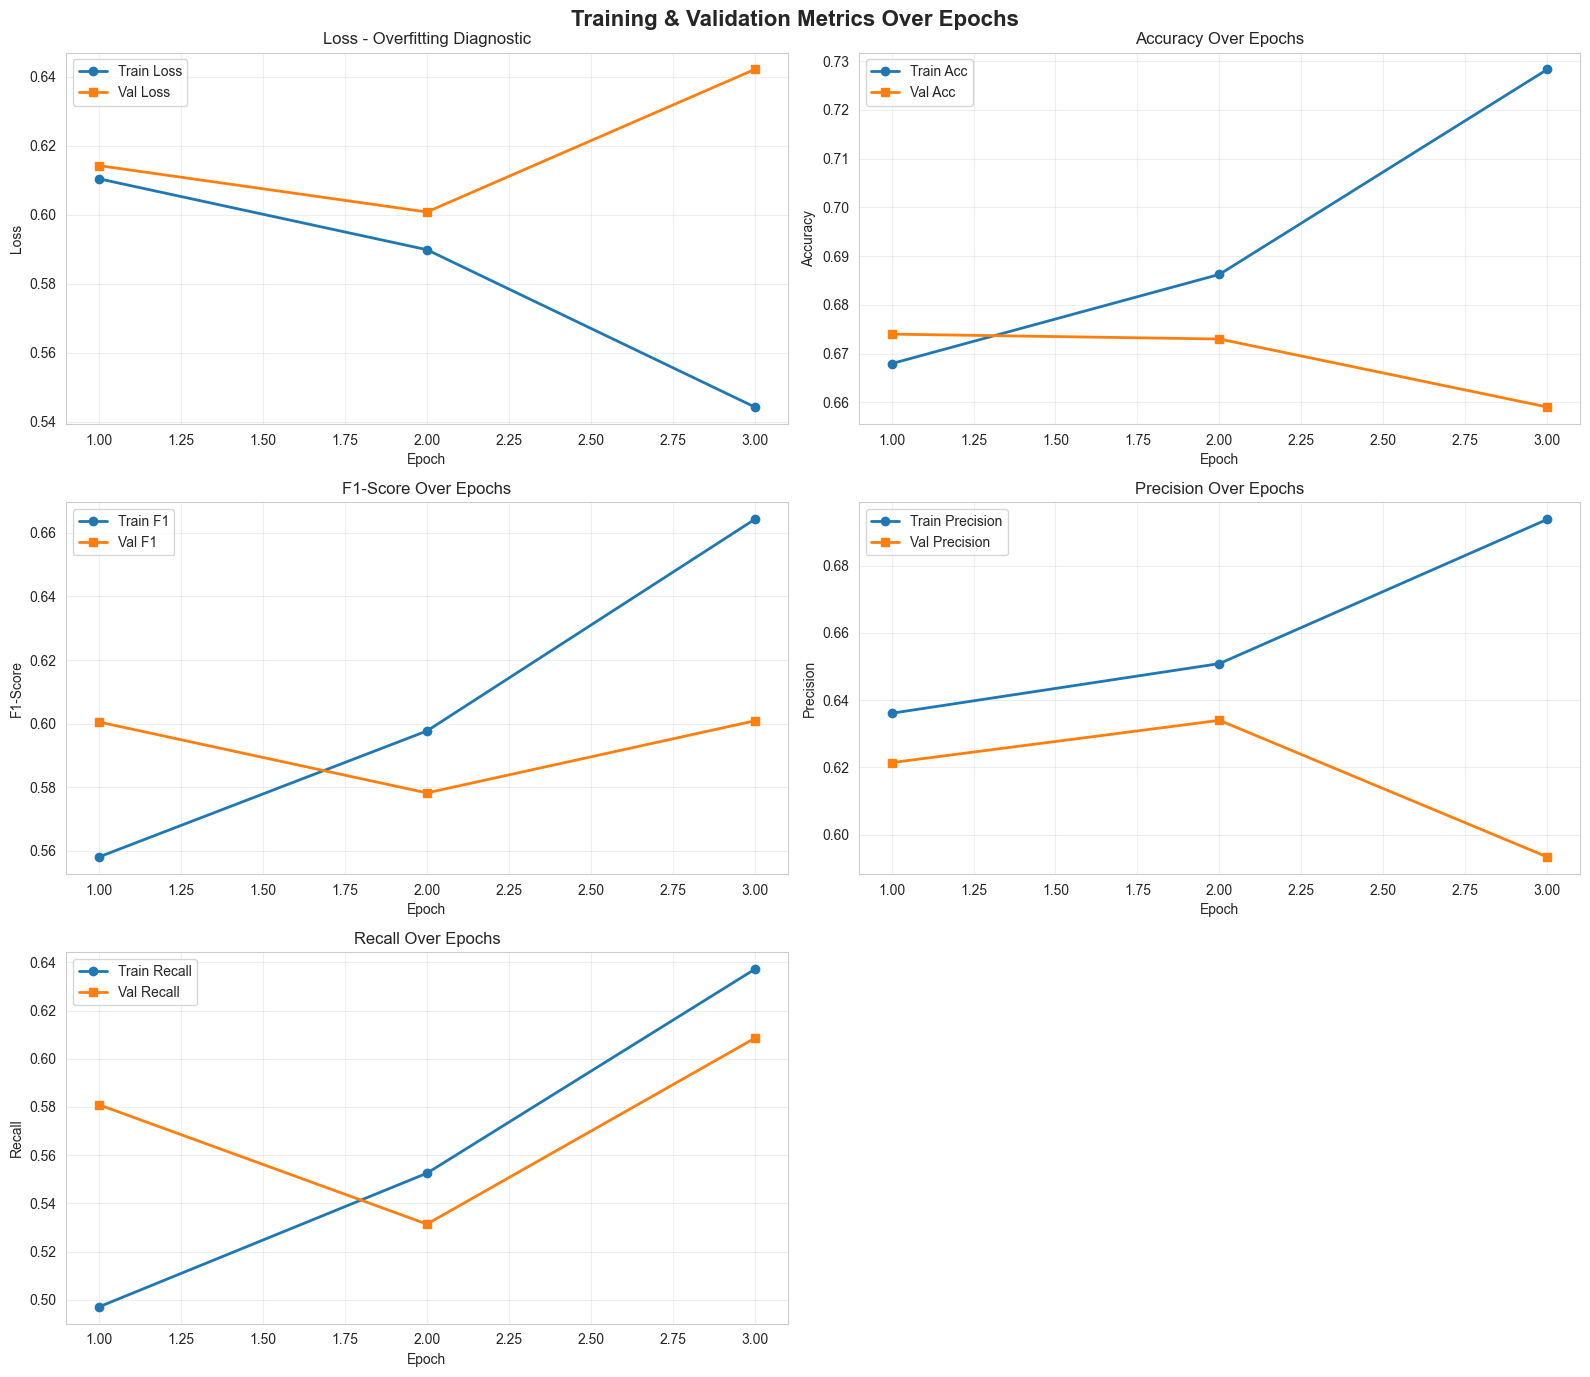

In [25]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create subplots for comprehensive training analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Training & Validation Metrics Over Epochs', fontsize=16, fontweight='bold')

# 1. Loss Curve
axes[0, 0].plot(history["epochs"], history["train_loss"], marker='o', label='Train Loss', linewidth=2)
axes[0, 0].plot(history["epochs"], history["val_loss"], marker='s', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss - Overfitting Diagnostic')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[0, 1].plot(history["epochs"], history["train_accuracy"], marker='o', label='Train Acc', linewidth=2)
axes[0, 1].plot(history["epochs"], history["val_accuracy"], marker='s', label='Val Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. F1-Score Curve
axes[1, 0].plot(history["epochs"], history["train_f1"], marker='o', label='Train F1', linewidth=2)
axes[1, 0].plot(history["epochs"], history["val_f1"], marker='s', label='Val F1', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score Over Epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision Curve
axes[1, 1].plot(history["epochs"], history["train_precision"], marker='o', label='Train Precision', linewidth=2)
axes[1, 1].plot(history["epochs"], history["val_precision"], marker='s', label='Val Precision', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision Over Epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Recall Curve
axes[2, 0].plot(history["epochs"], history["train_recall"], marker='o', label='Train Recall', linewidth=2)
axes[2, 0].plot(history["epochs"], history["val_recall"], marker='s', label='Val Recall', linewidth=2)
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Recall')
axes[2, 0].set_title('Recall Over Epochs')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].axis('off') 

plt.tight_layout()
plt.show()

## 10.4 Overfitting Diagnostics

In [26]:
train_loss_gap = history["train_loss"][-1] - history["val_loss"][-1]
train_acc_gap = history["train_accuracy"][-1] - history["val_accuracy"][-1]
train_loss_improvement = history["train_loss"][0] - history["train_loss"][-1]
val_loss_improvement = history["val_loss"][0] - history["val_loss"][-1]

print(f"\nFinal Epoch Statistics:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f} → Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Train Acc:  {history['train_accuracy'][-1]:.4f} → Val Acc:  {history['val_accuracy'][-1]:.4f}")
print(f"  Train F1:   {history['train_f1'][-1]:.4f} → Val F1:   {history['val_f1'][-1]:.4f}")

print(f"\nGap Analysis (Train - Val):")
print(f"  Loss Gap: {train_loss_gap:+.4f}")
print(f"  Acc Gap:  {train_acc_gap:+.4f}")

print(f"\nImprovement from Epoch 1 to Final:")
print(f"  Train Loss: {train_loss_improvement:+.4f}")
print(f"  Val Loss:   {val_loss_improvement:+.4f}")

if train_loss_gap > 0.1 or train_acc_gap > 0.1:
    print(f"\n⚠️  OVERFITTING DETECTED: Large gap between train and validation metrics")
else:
    print(f"\n✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned")


Final Epoch Statistics:
  Train Loss: 0.5443 → Val Loss: 0.6421
  Train Acc:  0.7283 → Val Acc:  0.6590
  Train F1:   0.6642 → Val F1:   0.6009

Gap Analysis (Train - Val):
  Loss Gap: -0.0978
  Acc Gap:  +0.0693

Improvement from Epoch 1 to Final:
  Train Loss: +0.0661
  Val Loss:   -0.0279

✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned


# 11. Testing / Final Evaluation

## 11.1 Load the trained model file

After the training the model is stored at `"../models/multimodal_model.pt"`. \
Loading the model and testing. To save time and compute

In [27]:
# Check if the file exists before loading
if not os.path.exists(MODEL_SAVE_PATH):
    print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
    print("Please ensure the model was saved correctly during training.")
else:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))

## 11.2 Test the model

In [28]:
test_results = evaluate(model, test_loader)
test_acc = test_results["Accuracy"]

print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.6667


## 11.3 Visualization

In [29]:
all_probs = test_results["probs"]
all_preds = test_results["preds"]
all_targets = test_results["targets"]

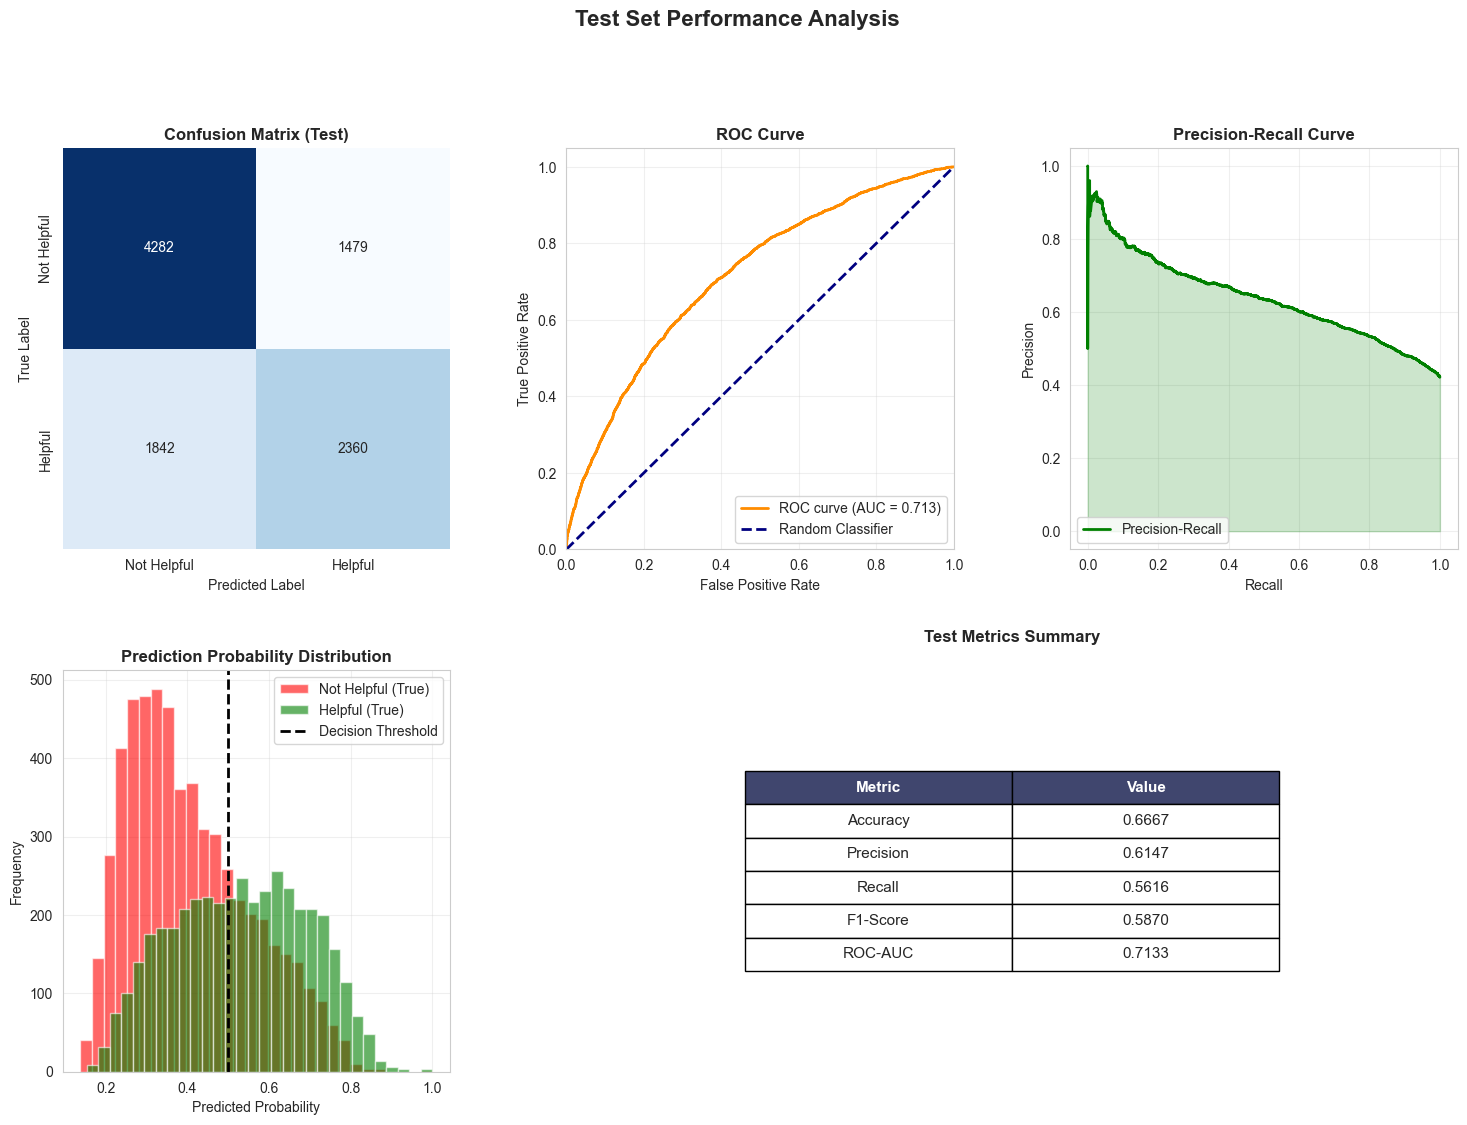

In [30]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm = test_results["Confusion Matrix"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix (Test)', fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
ax1.set_xticklabels(['Not Helpful', 'Helpful'])
ax1.set_yticklabels(['Not Helpful', 'Helpful'])

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
precision, recall, _ = precision_recall_curve(all_targets, all_probs)
ax3.plot(recall, precision, color='green', lw=2, label='Precision-Recall')
ax3.fill_between(recall, precision, alpha=0.2, color='green')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 4. Prediction Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(all_probs[all_targets == 0], bins=30, alpha=0.6, label='Not Helpful (True)', color='red')
ax4.hist(all_probs[all_targets == 1], bins=30, alpha=0.6, label='Helpful (True)', color='green')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Probability Distribution', fontweight='bold')
ax4.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Metrics Comparison Table
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('tight')
ax5.axis('off')

metrics_data = [
    ['Metric', 'Value'],
    ['Accuracy', f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{test_results['Precision']:.4f}"],
    ['Recall', f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{test_results['ROC-AUC']:.4f}"]
]

table = ax5.table(cellText=metrics_data, cellLoc='center', loc='center', 
                  colWidths=[0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax5.set_title('Test Metrics Summary', fontweight='bold', pad=20)

plt.suptitle('Test Set Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## 11.4 Metrics Visualization [Train, Validation, Test]

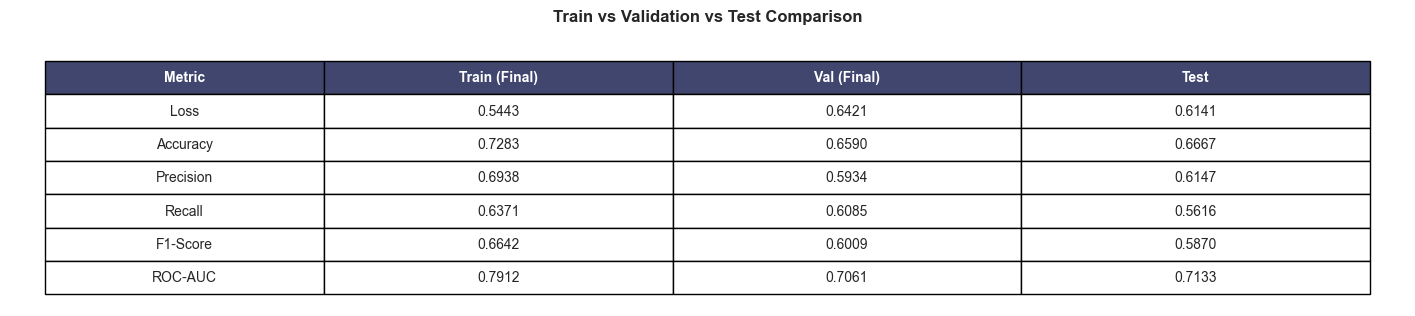

In [31]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')

comparison_data = [
    ['Metric', 'Train (Final)', 'Val (Final)', 'Test'],
    ['Loss', f"{history['train_loss'][-1]:.4f}", f"{history['val_loss'][-1]:.4f}", f"{test_results['Loss']:.4f}"],
    ['Accuracy', f"{history['train_accuracy'][-1]:.4f}", f"{history['val_accuracy'][-1]:.4f}", f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{history['train_precision'][-1]:.4f}", f"{history['val_precision'][-1]:.4f}", f"{test_results['Precision']:.4f}"],
    ['Recall', f"{history['train_recall'][-1]:.4f}", f"{history['val_recall'][-1]:.4f}", f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{history['train_f1'][-1]:.4f}", f"{history['val_f1'][-1]:.4f}", f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{history['train_roc_auc'][-1]:.4f}", f"{history['val_roc_auc'][-1]:.4f}", f"{test_results['ROC-AUC']:.4f}"],
]

comparison_table = ax6.table(cellText=comparison_data, cellLoc='center', loc='center',
                             colWidths=[0.2, 0.25, 0.25, 0.25])

comparison_table.auto_set_font_size(False)
comparison_table.set_fontsize(10)
comparison_table.scale(1, 2)

for i in range(4):
    comparison_table[(0, i)].set_facecolor('#40466e')
    comparison_table[(0, i)].set_text_props(weight='bold', color='white')

ax6.set_title('Train vs Validation vs Test Comparison', fontweight='bold', pad=20)

plt.show()

# 12. Error Analysis 

In [32]:
# Create comprehensive error analysis by modality
test_df_copy = test_df.reset_index(drop=True).copy()
test_df_copy['predicted_prob'] = all_probs
test_df_copy['predicted_label'] = all_preds
test_df_copy['true_label'] = all_targets
test_df_copy['is_correct'] = (test_df_copy['predicted_label'] == test_df_copy['true_label']).astype(int)

## 12.1 Metadata Analysis

In [33]:
# Analyze each metadata feature
metadata_error_analysis = {}

for col in METADATA_COLUMNS:
    if col in test_df_copy.columns:
        # Create bins for continuous features (5 bins)
        if test_df_copy[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            bins = pd.cut(test_df_copy[col], bins=5)
            error_rates = test_df_copy.groupby(bins)['is_correct'].apply(lambda x: 1 - x.mean())
            metadata_error_analysis[col] = error_rates
            
            print(f"\n  {col}:")
            for bin_range, error_rate in error_rates.items():
                count = (bins == bin_range).sum()
                print(f"    {bin_range}: Error Rate = {error_rate:.4f} ({count} reviews)")


  rating:
    (-1.561, -1.074]: Error Rate = 0.3779 (2331 reviews)
    (-1.074, -0.591]: Error Rate = 0.3553 (729 reviews)
    (-0.591, -0.107]: Error Rate = 0.3425 (835 reviews)
    (-0.107, 0.377]: Error Rate = 0.3202 (1268 reviews)
    (0.377, 0.861]: Error Rate = 0.3102 (4800 reviews)

  review_length:
    (-0.741, 2.45]: Error Rate = 0.3368 (9730 reviews)
    (2.45, 5.625]: Error Rate = 0.2041 (196 reviews)
    (5.625, 8.799]: Error Rate = 0.1154 (26 reviews)
    (8.799, 11.974]: Error Rate = 0.1429 (7 reviews)
    (11.974, 15.149]: Error Rate = 0.0000 (4 reviews)

  chars_per_word:
    (-3.291, 1.157]: Error Rate = 0.3395 (9207 reviews)
    (1.157, 5.583]: Error Rate = 0.2551 (737 reviews)
    (5.583, 10.01]: Error Rate = 0.4000 (15 reviews)
    (10.01, 14.436]: Error Rate = 0.0000 (1 reviews)
    (14.436, 18.863]: Error Rate = 0.3333 (3 reviews)

  image_bucket:
    (-0.258, 0.973]: Error Rate = 0.3334 (9253 reviews)
    (0.973, 2.197]: Error Rate = 0.4091 (374 reviews)
    (3.

In [34]:
print("\nMETADATA FEATURES (Overall error rates per feature):")
for col, error_rates in metadata_error_analysis.items():
    print(f"  {col}: Min={error_rates.min():.4f}, Max={error_rates.max():.4f}, Mean={error_rates.mean():.4f}")


METADATA FEATURES (Overall error rates per feature):
  rating: Min=0.3102, Max=0.3779, Mean=0.3412
  review_length: Min=0.0000, Max=0.3368, Mean=0.1598
  chars_per_word: Min=0.0000, Max=0.4000, Mean=0.2656
  image_bucket: Min=0.2299, Max=0.4091, Mean=0.3095
  days_since_first_review: Min=0.0625, Max=0.3649, Mean=0.2832
  is_verified: Min=0.3301, Max=0.3618, Mean=0.3459
  log_popularity: Min=0.2348, Max=0.3679, Mean=0.3165
  question_mark: Min=0.0000, Max=0.3336, Mean=0.1886
  exclamation_mark: Min=0.0000, Max=0.4400, Mean=0.2399
  title_length: Min=0.3109, Max=0.4000, Mean=0.3497
  title_to_text_ratio: Min=0.0000, Max=1.0000, Mean=0.4048


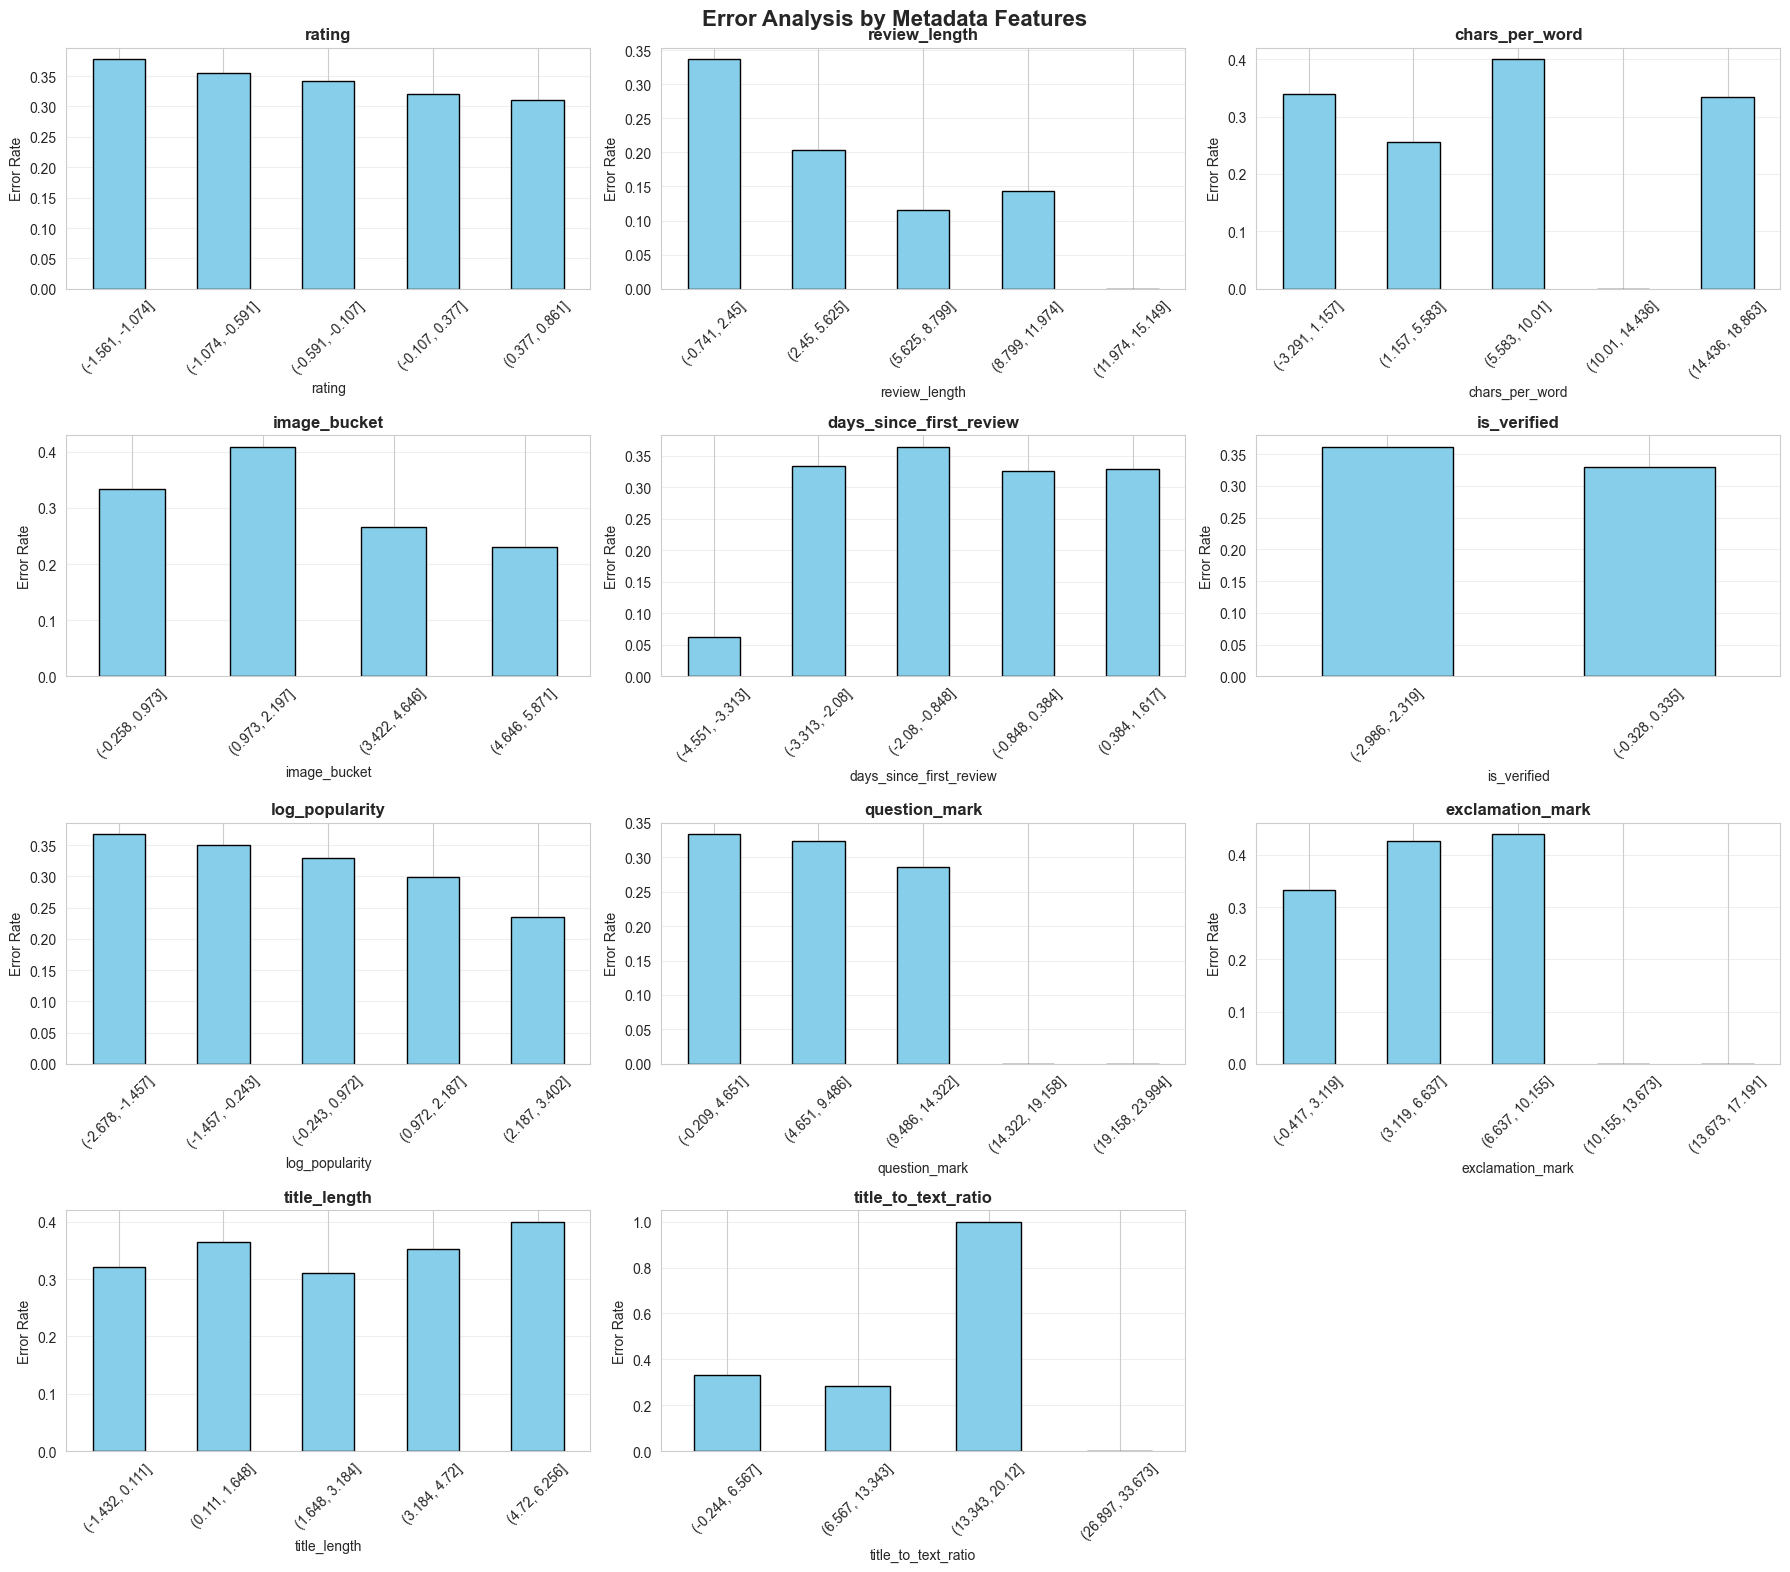

In [35]:
# Visualization: Error rate by metadata features
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
fig.suptitle('Error Analysis by Metadata Features', fontsize=16, fontweight='bold')

for idx, (col, error_rates) in enumerate(metadata_error_analysis.items()):
    if idx < len(axes):
        error_rates.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Error Rate')
        axes[idx].grid(True, alpha=0.3, axis='y')
        axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(metadata_error_analysis), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 12.2 Confusion Outcome Distribution

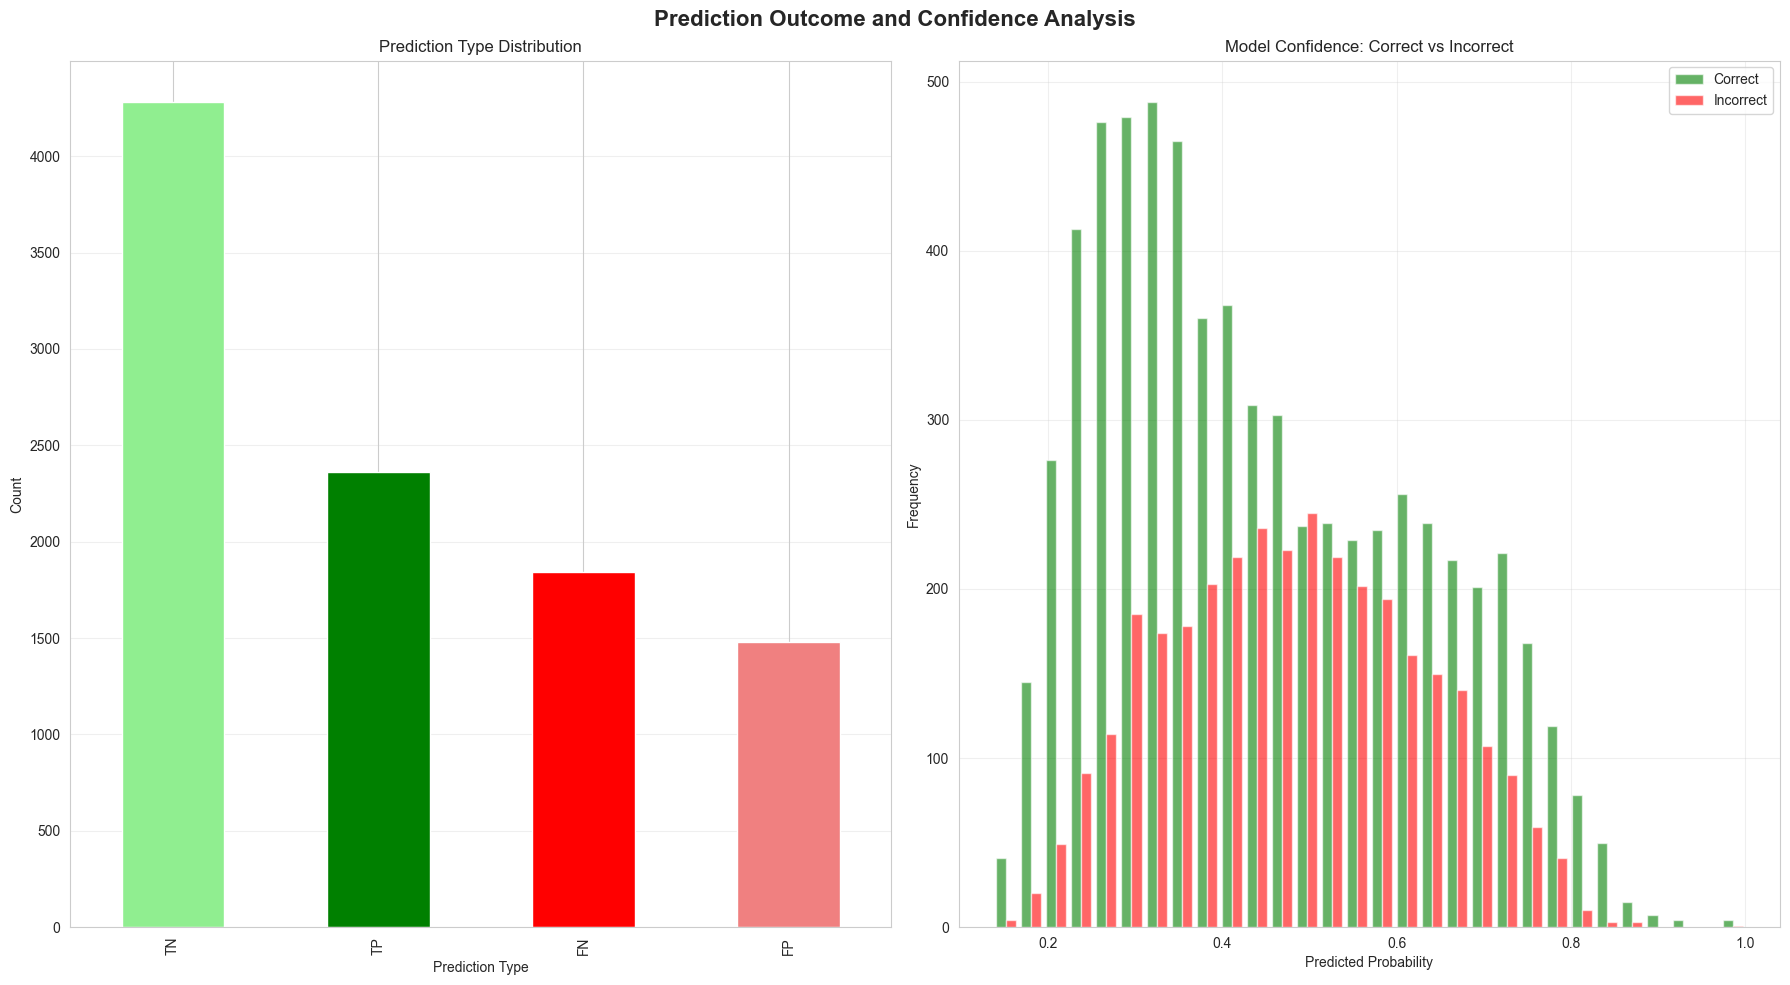

In [36]:
# Classify predictions and visualize error analysis
test_df_copy['error_type'] = test_df_copy.apply(
    lambda x: 'TP' if x['is_correct'] and x['predicted_label'] else
              'TN' if x['is_correct'] else
              'FP' if x['predicted_label'] else 'FN', axis=1
)

# Visualize error distribution and confidence
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Prediction Outcome and Confidence Analysis', fontsize=16, fontweight='bold')

# Error type distribution
error_counts = test_df_copy['error_type'].value_counts()
colors = {tp: c for tp, c in zip(['TP', 'TN', 'FP', 'FN'], ['green', 'lightgreen', 'lightcoral', 'red'])}
error_counts.plot(kind='bar', ax=axes[0], color=[colors.get(x, 'gray') for x in error_counts.index])
axes[0].set(title='Prediction Type Distribution', ylabel='Count', xlabel='Prediction Type')
axes[0].grid(True, alpha=0.3, axis='y')

# Model confidence distribution
correct = test_df_copy[test_df_copy['is_correct'] == 1]['predicted_prob']
incorrect = test_df_copy[test_df_copy['is_correct'] == 0]['predicted_prob']
axes[1].hist([correct, incorrect], bins=30, alpha=0.6, label=['Correct', 'Incorrect'], color=['green', 'red'])
axes[1].set(xlabel='Predicted Probability', ylabel='Frequency', title='Model Confidence: Correct vs Incorrect')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
print(f"\nMODEL CONFIDENCE ANALYSIS:")
print(f"  Mean confidence on correct predictions: {correct.mean():.4f}")
print(f"  Mean confidence on incorrect predictions: {incorrect.mean():.4f}")


MODEL CONFIDENCE ANALYSIS:
  Mean confidence on correct predictions: 0.4460
  Mean confidence on incorrect predictions: 0.4808


# 14 Explainability

## 14.1 Text

In [38]:
class TextModelWrapper:
    """Wrapper to make text predictions compatible with SHAP/LIME"""
    def __init__(self, model, tokenizer, device, max_length=MAX_TEXT_LENGTH):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
    
    def predict_text_only(self, texts):
        """Predict using only text (average probability across modalities)"""
        probs = []
        self.model.eval()
        
        with torch.no_grad():
            for text in texts:
                encoding = self.tokenizer(
                    text,
                    padding="max_length",
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt"
                )
                input_ids = encoding["input_ids"].to(self.device)
                attention_mask = encoding["attention_mask"].to(self.device)
                
                # Dummy image and metadata (neutral values)
                image = torch.zeros(1, 3, 224, 224).to(self.device)
                metadata = torch.zeros(1, len(METADATA_COLUMNS)).to(self.device)
                
                output = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    image=image,
                    metadata=metadata
                )
                prob = torch.sigmoid(output).cpu().numpy()[0]
                probs.append([1 - prob, prob])
        
        return np.array(probs)

In [39]:
# Select a sample review
sample_idx = 0
sample_text = test_df.iloc[sample_idx][TEXT_COLUMN]
true_label = test_df.iloc[sample_idx][LABEL_COLUMN]

print(f"Sample Text: {sample_text[:200]}...")
print(f"True Label: {'Helpful' if true_label == 1 else 'Not Helpful'}")

Sample Text: Get something more sturdy than this one! [SEP] I wanted to like this so I can shoot videos- first of all is hard to ply to get your phone to set in- then I was using it and the wind blew it down toget...
True Label: Not Helpful


In [40]:
# Create wrapper
text_wrapper = TextModelWrapper(model, tokenizer, device)

### LIME

In [41]:
# Create LIME explainer
explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=['Not Helpful', 'Helpful'],
    verbose=False
)

# Get explanation
explanation_lime = explainer_lime.explain_instance(
    sample_text,
    text_wrapper.predict_text_only,
    num_features=10,
    num_samples=100
)


LIME Top Contributing Words:
  SEP                  -0.0202  ↓ Not Helpful
  the                  +0.0164  ↑ Helpful
  phone                +0.0163  ↑ Helpful
  disaster             +0.0142  ↑ Helpful
  to                   +0.0137  ↑ Helpful
  shattered            +0.0135  ↑ Helpful
  I                    +0.0073  ↑ Helpful
  videos               +0.0068  ↑ Helpful
  wanted               +0.0026  ↑ Helpful
  sturdy               -0.0017  ↓ Not Helpful


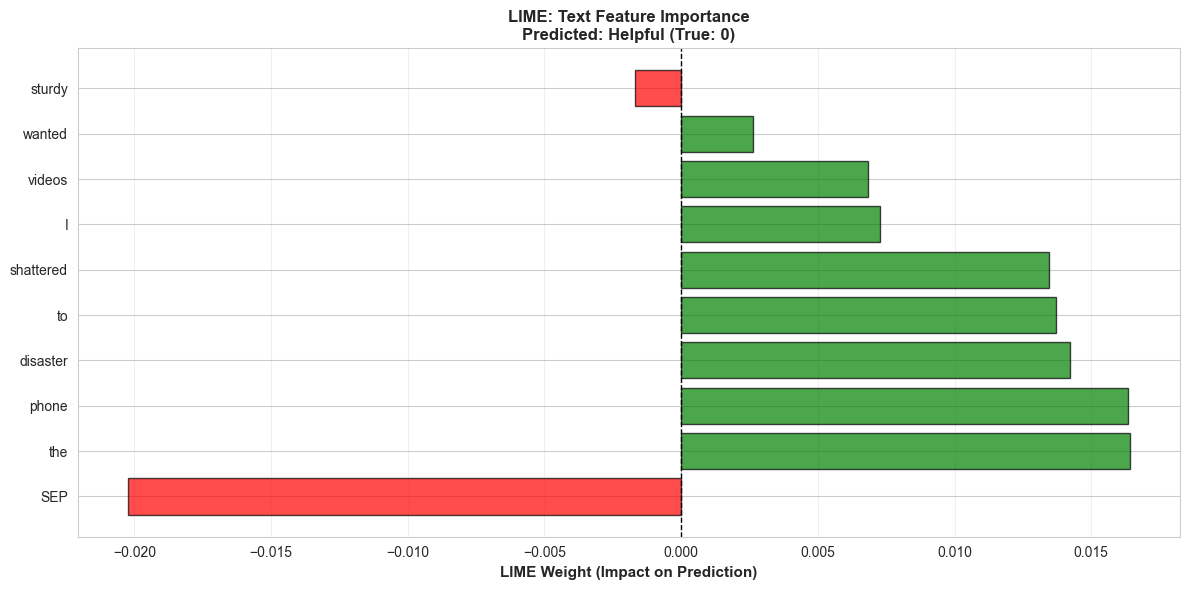

In [42]:
print(f"\nLIME Top Contributing Words:")
for word, weight in explanation_lime.as_list():
    sentiment = "↑ Helpful" if weight > 0 else "↓ Not Helpful"
    print(f"  {word:20s} {weight:+.4f}  {sentiment}")

# Visualize LIME explanation
fig, ax = plt.subplots(figsize=(12, 6))
weights = [weight for _, weight in explanation_lime.as_list()]
words = [word for word, _ in explanation_lime.as_list()]
colors = ['green' if w > 0 else 'red' for w in weights]

bars = ax.barh(range(len(words)), weights, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.set_xlabel('LIME Weight (Impact on Prediction)', fontsize=11, fontweight='bold')
ax.set_title(f'LIME: Text Feature Importance\nPredicted: Helpful (True: {true_label})', 
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### SHAP

In [43]:
# ---- SHAP EXPLANATION FOR TEXT ----
print("\n\nB. SHAP Explanation for Text (using kernel explainer):")

# Sample texts for SHAP background
background_texts = test_df.iloc[:50][TEXT_COLUMN].values

# Create SHAP explainer (kernel explainer for model-agnostic approach)
# Note: This is computationally expensive, so we use fewer background samples
def shap_predict_wrapper(texts):
    """Convert texts to predictions for SHAP"""
    return text_wrapper.predict_text_only(texts)[:, 1]  # Return probability of helpful

# For efficiency, we'll use a simpler approach: feature-based SHAP on tokenized text
print("(Simplified SHAP: Using token importance)")

sample_encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=MAX_TEXT_LENGTH,
    return_tensors="pt"
)
sample_tokens = tokenizer.convert_ids_to_tokens(sample_encoding['input_ids'][0])
sample_tokens = [t for t in sample_tokens if t != '[PAD]']

print(f"Sample tokenized text: {sample_tokens[:20]}")



B. SHAP Explanation for Text (using kernel explainer):
(Simplified SHAP: Using token importance)
Sample tokenized text: ['[CLS]', 'get', 'something', 'more', 'sturdy', 'than', 'this', 'one', '!', '[SEP]', 'i', 'wanted', 'to', 'like', 'this', 'so', 'i', 'can', 'shoot', 'videos']


## 14.2 Metadata

In [44]:
class MetadataModelWrapper:
    """Wrapper to make metadata predictions compatible with SHAP"""
    def __init__(self, model, device, scaler):
        self.model = model
        self.device = device
        self.scaler = scaler
    
    def predict_metadata_only(self, metadata_values):
        """Predict using only metadata (average probability across modalities)"""
        probs = []
        self.model.eval()
        
        with torch.no_grad():
            for row in metadata_values:

                # Dummy text and image
                input_ids = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(self.device)
                attention_mask = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(self.device)
                image = torch.zeros(1, 3, 224, 224).to(self.device)
                
                metadata = torch.tensor(row.astype(np.float32)).unsqueeze(0).to(self.device)
                
                output = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    image=image,
                    metadata=metadata
                )
                prob = torch.sigmoid(output).cpu().numpy()[0]
                probs.append(prob)
        
        return np.array(probs)

In [45]:
# Get sample metadata
sample_metadata_idx = 0
sample_metadata = test_df.iloc[sample_metadata_idx][METADATA_COLUMNS].values.reshape(1, -1)
sample_metadata_df = pd.DataFrame(sample_metadata, columns=METADATA_COLUMNS)
sample_metadata_scaled = scaler.transform(sample_metadata_df)[0]

print(f"Sample Metadata (Scaled):")
for col, val in zip(METADATA_COLUMNS, sample_metadata_scaled):
    print(f"  {col:25s}: {val:+.4f}")

Sample Metadata (Scaled):
  rating                   : -3.1054
  review_length            : -0.7318
  chars_per_word           : -9.6897
  image_bucket             : -0.7658
  days_since_first_review  : -5.6082
  is_verified              : -1.8702
  log_popularity           : -4.4638
  question_mark            : -0.4840
  exclamation_mark         : -0.0436
  title_length             : -1.4496
  title_to_text_ratio      : -0.2082


In [46]:
# Create wrapper
metadata_wrapper = MetadataModelWrapper(model, device, scaler)

### SHAP

In [47]:
# Create SHAP explainer for metadata
explainer_shap = shap.KernelExplainer(
    metadata_wrapper.predict_metadata_only,
    shap.sample(test_df[METADATA_COLUMNS].values, min(30, len(test_df))) 
)

# Get SHAP values for sample
shap_values = explainer_shap.shap_values(sample_metadata_scaled)

print(f"\nSHAP Values (Impact on Helpful Prediction):")
for col, val in zip(METADATA_COLUMNS, shap_values):
    sentiment = "↑ Helpful" if val > 0 else "↓ Not Helpful"
    print(f"  {col:25s}: {val:+.6f}  {sentiment}")


SHAP Values (Impact on Helpful Prediction):
  rating                   : +0.057660  ↑ Helpful
  review_length            : -0.016069  ↓ Not Helpful
  chars_per_word           : -0.002284  ↓ Not Helpful
  image_bucket             : -0.008944  ↓ Not Helpful
  days_since_first_review  : +0.086636  ↑ Helpful
  is_verified              : +0.004093  ↑ Helpful
  log_popularity           : +0.075744  ↑ Helpful
  question_mark            : -0.001761  ↓ Not Helpful
  exclamation_mark         : +0.000000  ↓ Not Helpful
  title_length             : +0.000237  ↑ Helpful
  title_to_text_ratio      : +0.001484  ↑ Helpful


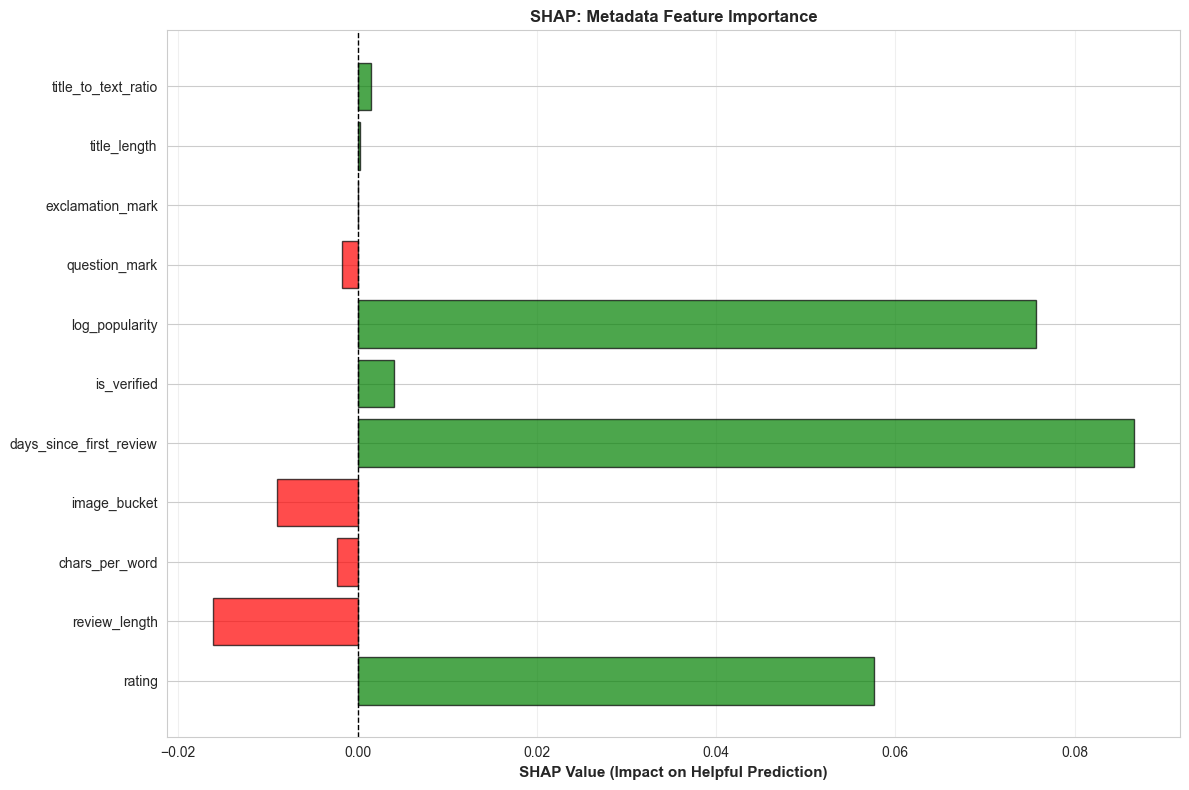

In [48]:
# Visualize SHAP explanation
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['green' if v > 0 else 'red' for v in shap_values]
bars = ax.barh(range(len(METADATA_COLUMNS)), shap_values, color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(METADATA_COLUMNS)))
ax.set_yticklabels(METADATA_COLUMNS, fontsize=10)
ax.set_xlabel('SHAP Value (Impact on Helpful Prediction)', fontsize=11, fontweight='bold')
ax.set_title('SHAP: Metadata Feature Importance', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 14.3 Images

In [49]:
class GradCAM:
    """Grad-CAM implementation for image feature importance"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activations)
        target_layer.register_full_backward_hook(self.save_gradients)
    
    def save_activations(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor):
        """Generate Class Activation Map"""
        # Forward pass
        output = self.model(
            input_ids=input_tensor['input_ids'],
            attention_mask=input_tensor['attention_mask'],
            image=input_tensor['image'],
            metadata=input_tensor['metadata']
        )
        
        # Backward pass
        self.model.zero_grad()
        output.backward()
        
        # Handle both 3D and 4D gradient/activation arrays
        gradients = self.gradients.cpu().data.numpy()
        activations = self.activations.cpu().data.numpy()
        
        # If 4D (batch, channels, height, width), take first batch
        if gradients.ndim == 4:
            gradients = gradients[0]
            activations = activations[0]
        
        # Now gradients/activations should be [C, H, W]
        if gradients.ndim != 3:
            print(f"Warning: Unexpected gradient shape {gradients.shape}, skipping CAM")
            return np.zeros((224, 224))
        
        # Weight gradients by average gradient
        weights = np.mean(gradients, axis=(1, 2))  # [C]
        
        # Compute weighted sum
        cam = np.zeros(activations.shape[1:])  # [H, W]
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
        
        # Apply ReLU
        cam = np.maximum(cam, 0)
        
        # Normalize
        cam = cam / (cam.max() + 1e-8)
        
        return cam

In [50]:
# Get sample image - find first valid one
sample_image_idx = None
sample_image_path = None

for idx in range(len(test_df)):
    path = test_df.iloc[idx][IMAGE_PATH_COLUMN]
    if pd.notna(path) and isinstance(path, str):
        sample_image_idx = idx
        sample_image_path = path
        break

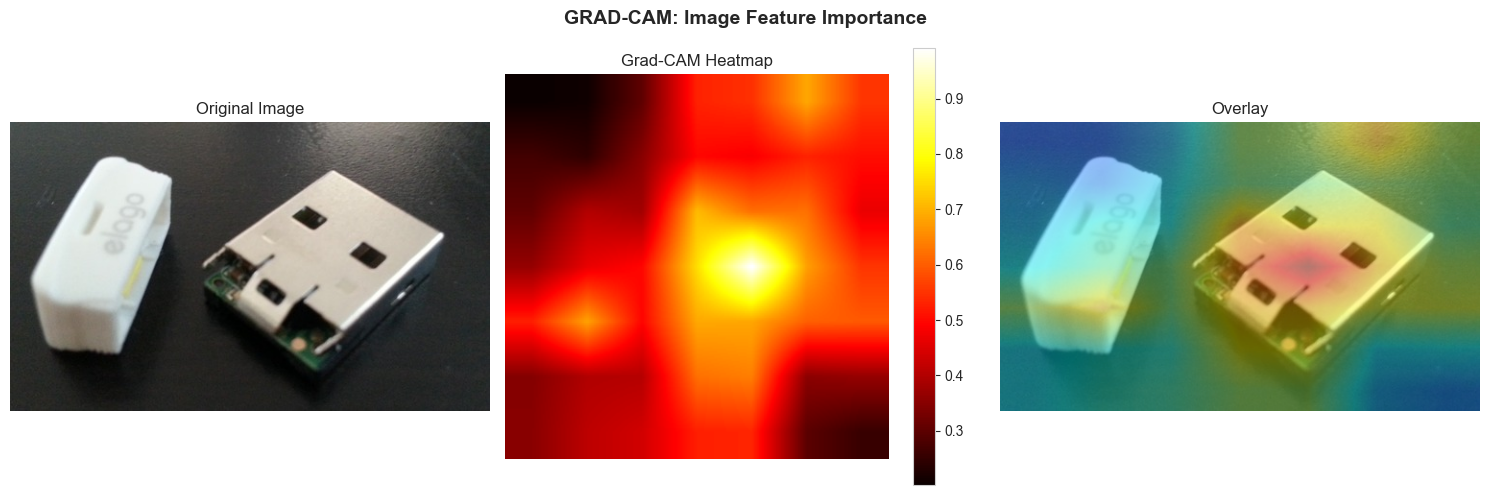

Grad-CAM generated for image: ../data\images\25550.jpg
  Heatmap shows regions important for model prediction
  Red regions: High importance, Green regions: Low importance


In [52]:
if sample_image_idx is not None and sample_image_path is not None:
    full_image_path = sample_image_path
    
    if os.path.exists(full_image_path):
        # Load and process image
        sample_image = Image.open(full_image_path).convert("RGB")
        sample_image_tensor = image_transform(sample_image).unsqueeze(0).to(device)
        
        # Dummy text and metadata
        sample_input_ids = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
        sample_attention_mask = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
        sample_metadata = torch.zeros(1, len(METADATA_COLUMNS)).to(device)
        
        input_dict = {
            'input_ids': sample_input_ids,
            'attention_mask': sample_attention_mask,
            'image': sample_image_tensor,
            'metadata': sample_metadata
        }
        
        # Create Grad-CAM - hook into features layer for spatial dimensions
        grad_cam = GradCAM(model, model.image_encoder.features[-1])
        cam = grad_cam.generate_cam(input_dict)
        
        # Resize CAM to original image size
        cam_resized = cv2.resize(cam, (224, 224))
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle('GRAD-CAM: Image Feature Importance', fontsize=14, fontweight='bold')
        
        # Original image
        img_array = np.array(sample_image)
        axes[0].imshow(img_array)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        # CAM heatmap
        im = axes[1].imshow(cam_resized, cmap='hot')
        axes[1].set_title('Grad-CAM Heatmap')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1])
        
        # Overlay - ensure CAM matches original image dimensions
        cam_resized = cv2.resize(cam, (img_array.shape[1], img_array.shape[0]))  # (width, height)
        overlay = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
        blended = cv2.addWeighted(img_array, 0.6, overlay, 0.4, 0)
        
        axes[2].imshow(blended)
        axes[2].set_title('Overlay')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Grad-CAM generated for image: {sample_image_path}")
        print(f"  Heatmap shows regions important for model prediction")
        print(f"  Red regions: High importance, Green regions: Low importance")
    else:
        print(f"Warning: Full image path not found: {full_image_path}")
        print("Skipping Grad-CAM visualization")
else:
    print("Warning: No images found in test set")
    print("Skipping Grad-CAM visualization")

# 15. Inference Pipeline

In [ ]:
def predict(model, text, image_path, metadata_values, device=None):
    """Generate prediction for a single instance."""
    import joblib
    
    # Resolve device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.eval()
    
    # Load scaler for metadata normalization
    if not os.path.exists(MODEL_METADATA_SAVE_PATH):
        raise FileNotFoundError(f"Scaler not found at {MODEL_METADATA_SAVE_PATH}. Please train the model first.")
    scaler = joblib.load(MODEL_METADATA_SAVE_PATH)
    
    # Text - create tensor and move to device immediately
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    # Image - handle missing/corrupted files gracefully
    if not os.path.exists(image_path):
        print(f"Warning: Image not found at {image_path}, using placeholder")
        image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    else:
        try:
            image = Image.open(image_path).convert("RGB")
            image = image_transform(image).unsqueeze(0).to(device)
        except Exception as e:
            print(f"Warning: Could not load image: {e}, using placeholder")
            image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    
    # Metadata - validate, scale, and move to device
    if len(metadata_values) != len(METADATA_COLUMNS):
        raise ValueError(f"Expected {len(METADATA_COLUMNS)} metadata values, got {len(metadata_values)}")
    
    # Scale metadata using trained scaler
    metadata_scaled = scaler.transform([metadata_values])[0]
    metadata = torch.tensor(metadata_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata
        )
        prob = torch.sigmoid(output).item()
    
    return prob

In [ ]:
prob = predict(
    model=model,
    text="Great product! Very satisfied.",
    image_path="../data/images/123.jpg",
    metadata_values=[5, 150, 4.2, 1.0, 45, 1, 3.5, 2, 1, 0, 120, 0.8],
    device="cuda"
)
print(f"Probability this review is helpful: {prob:.2%}")